In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# lib's
#2
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.applications import VGG16

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Reshape, Input
from tensorflow.keras.layers import LeakyReLU

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, cohen_kappa_score, log_loss
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

from PIL import Image

import json

# !pip install sentence-transformers
from sentence_transformers import SentenceTransformer, util
import torch

import csv

In [ ]:
# To unzip
#3
from zipfile import ZipFile
file_name = "/content/drive/MyDrive/AWA2_dataset/AWA2_Balanced_main_dataset.zip"
with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('done')

done


In [ ]:
!pip install split-folders
#4

import splitfolders
splitfolders.ratio(r"/content/Trail_balanced_train_class_awa2",  # "/content/processed/train"
                   'data',
                   seed = 41,
                   ratio = (0.7, 0.15, 0.15)) # train/val/test

Copying files: 9020 files [00:25, 352.18 files/s]


In [ ]:
# variables
#4
train_data_path = "/content/data/train"
val_data_path = "/content/data/val"
test_data_path = "/content/data/test"



In [ ]:
# Load and Preprocess Images
#5
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = datagen.flow_from_directory(train_data_path, target_size=(224, 224), batch_size=32, class_mode='categorical')
val_data = datagen.flow_from_directory(val_data_path, target_size=(224, 224), batch_size=32, class_mode='categorical')
test_data = datagen.flow_from_directory(test_data_path, target_size=(224, 224), batch_size=32, class_mode='categorical')


Found 6314 images belonging to 18 classes.
Found 1353 images belonging to 18 classes.
Found 1353 images belonging to 18 classes.


In [ ]:
# Build a DCGAN
# Generator (Feature Generator)

def build_generator(noise_dim, output_dim):
    input_noise = Input(shape=(noise_dim,))
    x = Dense(128, activation='relu')(input_noise)
    x = Dense(output_dim, activation='linear')(x)  # match feature vector size
    model = Model(input_noise, x)
    return model

# Discriminator

def build_discriminator(input_dim):
    input_feat = Input(shape=(input_dim,))
    x = Dense(128)(input_feat)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(1, activation='sigmoid')(x)
    model = Model(input_feat, x)
    return model
img_path = "/content/drive/MyDrive/AWA2_dataset/Test classes/leopard/leopard_10001.jpg"
show_prediction(img_path)

In [ ]:
# Feature Extractor

def build_feature_extractor():
    base_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
    return base_model

# Create the feature extractor
feature_extractor = build_feature_extractor()

In [ ]:
# Train the GAN

# Assumptions
noise_dim = 100
feature_dim = 512  # e.g., from CNN like VGG16 with global average pooling
batch_size = 64
epochs = 11 # 10000

generator = build_generator(noise_dim, feature_dim)
discriminator = build_discriminator(feature_dim)

# Compile discriminator
discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Freeze discriminator during generator training
discriminator.trainable = False

# GAN = generator + discriminator
noise_input = tf.keras.Input(shape=(noise_dim,))
generated_feature = generator(noise_input)
validity = discriminator(generated_feature)

gan = tf.keras.Model(noise_input, validity)
gan.compile(optimizer='adam', loss='binary_crossentropy')

# Prepare real feature vectors
real_features, real_labels = [], []
for X, y in train_data:
    feat = feature_extractor.predict(X)
    real_features.append(feat)
    real_labels.append(y)
    if len(real_features)*batch_size > 10000:
        break

real_features = np.vstack(real_features)
real_labels = np.argmax(np.vstack(real_labels), axis=1)

# Training loop
for epoch in range(epochs):
    # ---------------------
    # Train Discriminator
    # ---------------------
    idx = np.random.randint(0, real_features.shape[0], batch_size)
    real_feat_batch = real_features[idx]

    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    fake_feat_batch = generator.predict(noise)

    # Labels
    real_y = np.ones((batch_size, 1))
    fake_y = np.zeros((batch_size, 1))

    # Train discriminator
    d_loss_real = discriminator.train_on_batch(real_feat_batch, real_y)
    d_loss_fake = discriminator.train_on_batch(fake_feat_batch, fake_y)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # ---------------------
    # Train Generator
    # ---------------------
    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    valid_y = np.ones((batch_size, 1))  # Trick GAN: fake should be labeled real

    g_loss = gan.train_on_batch(noise, valid_y)

    if epoch % 10 == 0:
        print(f"{epoch} [D loss: {d_loss[0]} | D acc.: {100*d_loss[1]:.2f}] [G loss: {g_loss:.4f}]")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [D loss: 0.4122470021247864 | D acc.: 84.77] [G loss: 0.8748]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
10 [D loss: 2.057229995727539 | D acc.: 44.79] [G loss: 0.1508]


In [ ]:
# Feature Extraction + Label Collection

X_train_features = []
y_train_labels = []

# Loop over train_data batches
for images, labels in train_data:
    features = feature_extractor.predict(images)
    X_train_features.append(features)
    y_train_labels.append(np.argmax(labels, axis=1))  # assuming categorical class_mode

    # Optional: break early if too large
    if len(X_train_features) * train_data.batch_size > 10000:
        break

# Stack all batches into arrays
X_train_features = np.vstack(X_train_features)
y_train_labels = np.concatenate(y_train_labels)


1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step


KeyboardInterrupt: 

In [ ]:
# Classification Model on Generated Features

# Train RF classifier on generated + real features (with labels)
rf_model = RandomForestClassifier()
rf_model.fit(X_train_features, y_train_labels)


RandomForestClassifier()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       566
           1       1.00      1.00      1.00       556
           2       1.00      1.00      1.00       534
           3       1.00      1.00      1.00       546
           4       1.00      1.00      1.00       533
           5       1.00      1.00      1.00       549
           6       1.00      1.00      1.00       560
           7       1.00      1.00      1.00       535
           8       1.00      1.00      1.00       550
           9       1.00      1.00      1.00       550
          10       1.00      1.00      1.00       559
          11       1.00      1.00      1.00       558
          12       1.00      1.00      1.00       535
          13       1.00      1.00      1.00       558
          14       1.00      1.00      1.00       573
          15       1.00      1.00      1.00       557
          16       1.00      1.00      1.00       598
          17       1.00    

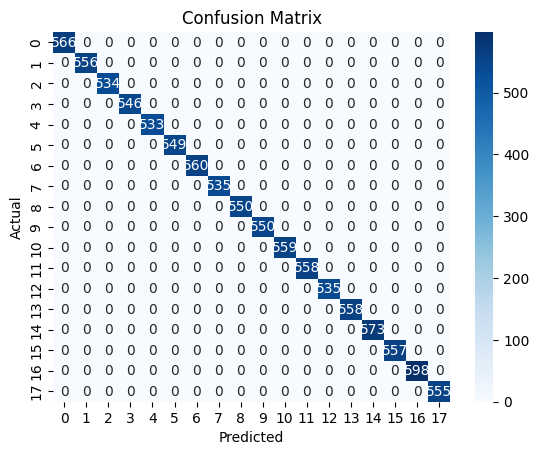

In [ ]:
# Evaluate Model

y_pred = rf_model.predict(X_train_features)

print(classification_report(y_train_labels, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_train_labels, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# Extract Test Features

X_test_features = []
y_test_labels = []

# Loop over test_data batches
for images, labels in test_data:
    features = feature_extractor.predict(images)
    X_test_features.append(features)
    y_test_labels.append(np.argmax(labels, axis=1))  # if using categorical labels

    # Optional: limit size
    if len(X_test_features) * test_data.batch_size > 1000:
        break

# Stack arrays
X_test_features = np.vstack(X_test_features)
y_test_labels = np.concatenate(y_test_labels)


NameError: name 'test_data' is not defined

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        54
           1       0.79      0.89      0.84        56
           2       0.93      0.95      0.94        57
           3       0.84      0.75      0.79        55
           4       0.88      0.79      0.83        63
           5       0.93      0.96      0.94        52
           6       0.76      0.78      0.77        60
           7       0.98      0.97      0.97        60
           8       0.81      0.84      0.82        55
           9       0.89      0.79      0.84        53
          10       0.80      0.92      0.86        52
          11       1.00      0.93      0.96        55
          12       0.98      0.95      0.96        58
          13       0.92      0.93      0.93        60
          14       0.96      0.93      0.95        58
          15       0.90      0.91      0.91        58
          16       0.99      1.00      0.99        66
          17       0.91    

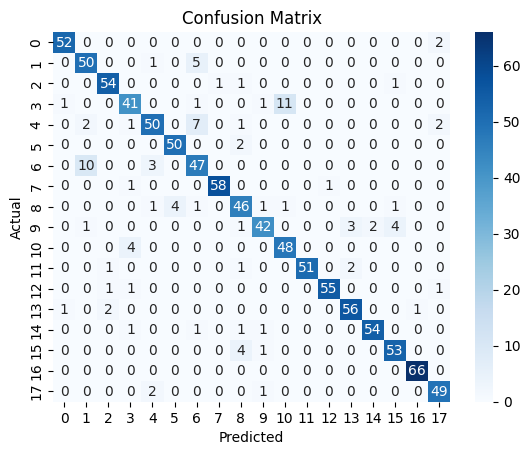

In [ ]:
# Evaluate Model

y_pred = rf_model.predict(X_test_features)

print(classification_report(y_test_labels, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# Feature Extraction + Label Collection

X_val_features = []
y_val_labels = []

# Loop over train_data batches
for images, labels in val_data:
    features = feature_extractor.predict(images)
    X_val_features.append(features)
    y_val_labels.append(np.argmax(labels, axis=1))  # assuming categorical class_mode

    # Optional: break early if too large
    if len(X_val_features) * val_data.batch_size > 10000:
        break

# Stack all batches into arrays
X_val_features = np.vstack(X_val_features)
y_val_labels = np.concatenate(y_val_labels)


NameError: name 'val_data' is not defined

              precision    recall  f1-score   support

           0       1.00      0.97      0.99       545
           1       0.78      0.95      0.86       545
           2       0.97      0.89      0.93       540
           3       0.87      0.80      0.84       546
           4       0.85      0.84      0.85       547
           5       0.96      0.96      0.96       536
           6       0.84      0.82      0.83       556
           7       0.96      1.00      0.98       543
           8       0.80      0.85      0.82       549
           9       0.81      0.84      0.83       544
          10       0.83      0.90      0.87       547
          11       0.93      0.95      0.94       553
          12       0.96      0.92      0.94       537
          13       0.95      0.84      0.90       547
          14       0.93      0.95      0.94       548
          15       0.96      0.90      0.93       550
          16       1.00      0.99      0.99       577
          17       0.95    

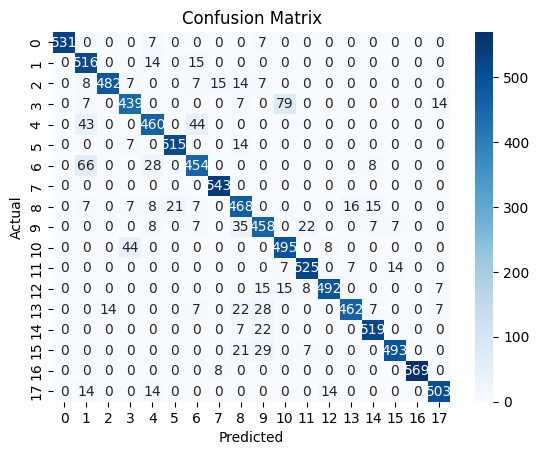

In [ ]:
# Evaluate Model

y_pred = rf_model.predict(X_val_features)

print(classification_report(y_val_labels, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_val_labels, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# Save the Model and Features

# Save RF model
joblib.dump(rf_model, 'zsl_classifier_rf.pkl')

# Save CNN Feature Extractor
feature_extractor = build_feature_extractor()
feature_extractor.save('cnn_feature_extractor.h5')


In [ ]:
#6
idx_to_class = {v: k for k, v in train_data.class_indices.items()}

# Save
with open('idx_to_class.json', 'w') as f:
    json.dump(idx_to_class, f)

# Load
with open('idx_to_class.json', 'r') as f:
    idx_to_class = json.load(f)


In [ ]:
# Predict on a New Image
#7

# Load models
rf_model = joblib.load('/content/drive/MyDrive/model_file/zsl_classifier_rf.pkl')
feature_extractor = load_model('/content/drive/MyDrive/model_file/cnn_feature_extractor.h5')

# Reverse the class_indices from train_data
# print(train_data.class_indices)
idx_to_class = {v: k for k, v in train_data.class_indices.items()}

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    features = feature_extractor.predict(img_array)
    probs = rf_model.predict_proba(features)[0]
    predicted_class = rf_model.classes_[np.argmax(probs)]

    # Get class name from index
    class_name = idx_to_class[predicted_class]

    print(f"Predicted Class: {predicted_class}")
    print(f"Class Name: {class_name}")
    print(f"Probability: {np.max(probs):.4f}")
    return predicted_class, class_name, probs



In [ ]:
# Visualize Prediction
#8
def show_prediction(img_path):

    predicted_class, class_name, probs = predict_image(img_path)

    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} - {class_name} || ({np.max(probs)*100:.2f}%)")
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class: 16
Class Name: tiger
Probability: 0.3800


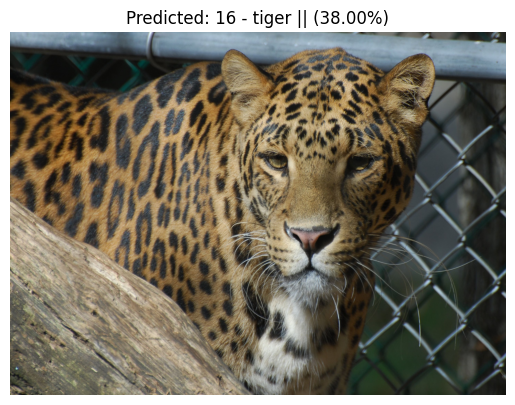

In [ ]:

#9
img_path = "/content/drive/MyDrive/AWA2_dataset/Test classes/leopard/leopard_10001.jpg"
show_prediction(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Predicted Class: 13
Class Name: siamese_cat
Probability: 0.3200


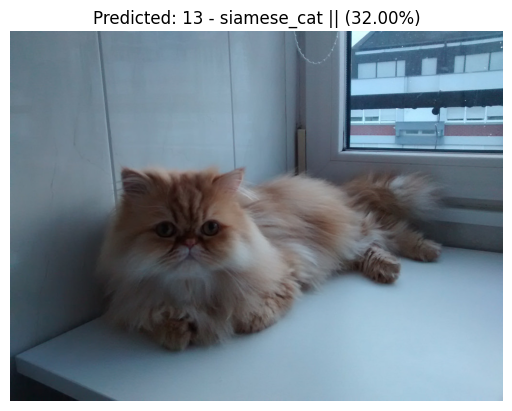

In [ ]:
img_path = "/content/drive/MyDrive/AWA2_dataset/Test classes/persian_cat/persian+cat_10001.jpg"
show_prediction(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted Class: 8
Class Name: monkey
Probability: 0.4000


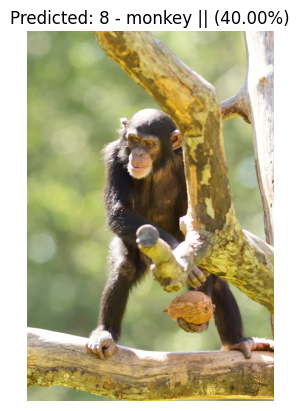

In [ ]:
img_path = "/content/drive/MyDrive/AWA2_dataset/Test classes/chimpanzee/chimpanzee_10001.jpg"
show_prediction(img_path)

# TO get prediction with generator model#

In [ ]:
import json

# Load your saved JSON mapping
with open("/content/idx_to_class.json", "r") as f:
    idx_to_class = json.load(f)


In [ ]:
#10
def prediction_generator(image_paths):
    for img_path in image_paths:
        try:
            act_class = img_path.split('/')[-2]

            # Preprocess image
            img = image.load_img(img_path, target_size=(224, 224))
            img_array = image.img_to_array(img)
            img_array = preprocess_input(img_array)
            img_array = np.expand_dims(img_array, axis=0)

            # Extract features & predict
            features = feature_extractor.predict(img_array)
            probs = rf_model.predict_proba(features)[0]
            predicted_class = rf_model.classes_[np.argmax(probs)]
            print(predicted_class)
            [str(predicted_class)]
            # class_name = idx_to_class[predicted_class]
            class_name = idx_to_class[str(predicted_class)]

            print(class_name)
            confidence = np.max(probs)

            # CSV output file
            csv_file_path = "prediction_results_generator.csv"

            # Write header once
            if not os.path.exists(csv_file_path):
                with open(csv_file_path, mode='w', newline='') as f:
                    writer = csv.writer(f)
                    writer.writerow(["Image Path", "Actual Class", "Predicted Class", "Class Name", "Probability"])

            # Log to CSV
            with open(csv_file_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([img_path, act_class, predicted_class, class_name, f"{confidence:.4f}"])

            # Yield the result
            yield {
                "img_path": img_path,
                "act_class": act_class,
                "predicted_class": predicted_class,
                "class_name": class_name,
                "confidence": confidence
            }

        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

# Predict for all images in a folder
import glob

img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test/*/*"   # '../Dataset/artefact2/test/*/*'
image_paths = glob.glob(img_dir)

for result in prediction_generator(image_paths):
    print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step
15
squirrel
{'img_path': '/content/drive/MyDrive/AWA2_dataset/Trial_test/raccoon/raccoon_10005.jpg', 'act_class': 'raccoon', 'predicted_class': np.int64(15), 'class_name': 'squirrel', 'confidence': np.float64(0.25)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 930ms/step
15
squirrel
{'img_path': '/content/drive/MyDrive/AWA2_dataset/Trial_test/raccoon/raccoon_10008.jpg', 'act_class': 'raccoon', 'predicted_class': np.int64(15), 'class_name': 'squirrel', 'confidence': np.float64(0.2)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 974ms/step
9
mouse
{'img_path': '/content/drive/MyDrive/AWA2_dataset/Trial_test/raccoon/raccoon_10004.jpg', 'act_class': 'raccoon', 'predicted_class': np.int64(9), 'class_name': 'mouse', 'confidence': np.float64(0.2)}
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
5
gorilla
{'img_path': '/content/drive/MyDrive/AWA2_dataset/Trial_test/raccoon/raccoon_10007.jpg', 'act_class': 'raccoon', 'predicted_class': np.int64(5), 'class_name': 'gorilla', 'confidence': np.float64(0

In [ ]:
# CSV output file
csv_file_path = "prediction_results_generator.csv"
df = pd.read_csv(csv_file_path)
df.head()

,Image Path,Actual Class,Predicted Class,Class Name,Probability
0,/content/drive/MyDrive/AWA2_dataset/Trial_test...,raccoon,15,squirrel,0.25
1,/content/drive/MyDrive/AWA2_dataset/Trial_test...,raccoon,15,squirrel,0.20
2,/content/drive/MyDrive/AWA2_dataset/Trial_test...,raccoon,9,mouse,0.20
3,/content/drive/MyDrive/AWA2_dataset/Trial_test...,raccoon,5,gorilla,0.14
4,/content/drive/MyDrive/AWA2_dataset/Trial_test...,raccoon,11,rabbit,0.16


#Follwoing code upload generator result then find similarity using below code using transformer#

#To check for complete AWA2 dataset using MINI LAMA #

In [ ]:
def prediction_generator(image_paths):
    for img_path in image_paths:
        try:
            act_class = img_path.split('/')[-2]

            # Preprocess image
            img = image.load_img(img_path, target_size=(224, 224))
            img_array = image.img_to_array(img)
            img_array = preprocess_input(img_array)
            img_array = np.expand_dims(img_array, axis=0)

            # Extract features & predict
            features = feature_extractor.predict(img_array)
            probs = rf_model.predict_proba(features)[0]
            predicted_class = rf_model.classes_[np.argmax(probs)]

            # Robust mapping
            pred_key = predicted_class
            if pred_key not in idx_to_class:
                pred_key = str(pred_key)
            if pred_key not in idx_to_class:
                pred_key = int(pred_key)
            class_name = idx_to_class[pred_key]

            confidence = np.max(probs)

            # CSV output file
            csv_file_path = "prediction_results_generator_complete_AWA2_dataset.csv"

            # Write header once
            if not os.path.exists(csv_file_path):
                with open(csv_file_path, mode='w', newline='') as f:
                    writer = csv.writer(f)
                    writer.writerow(["Image Path", "Actual Class", "Predicted Class", "Class Name", "Probability"])

            # Log to CSV
            with open(csv_file_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([img_path, act_class, predicted_class, class_name, f"{confidence:.4f}"])

            yield {
                "img_path": img_path,
                "act_class": act_class,
                "predicted_class": predicted_class,
                "class_name": class_name,
                "confidence": confidence
            }

        except Exception:
            continue


import glob
import os

img_dir = "/content/drive/MyDrive/AWA2_dataset/Test classes/*/*"   # '../Dataset/artefact2/test/*/*'
image_paths = glob.glob(img_dir)

# Run the generator (no printing)
for _ in prediction_generator(image_paths):
    pass


Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

In [ ]:
# CSV output file
csv_file_path = "prediction_results_generator_complete_AWA2_dataset.csv"
df = pd.read_csv(csv_file_path)
df.head()

,Image Path,Actual Class,Predicted Class,Class Name,Probability
0,/content/drive/MyDrive/AWA2_dataset/Test class...,raccoon,3,cow,0.21
1,/content/drive/MyDrive/AWA2_dataset/Test class...,raccoon,9,mouse,0.21
2,/content/drive/MyDrive/AWA2_dataset/Test class...,raccoon,8,monkey,0.15
3,/content/drive/MyDrive/AWA2_dataset/Test class...,raccoon,8,monkey,0.15
4,/content/drive/MyDrive/AWA2_dataset/Test class...,raccoon,13,siamese_cat,0.23


In [ ]:

#11
import pandas as pd
import torch
import os
from sentence_transformers import SentenceTransformer, util

# ==== LOAD CSV ====
csv_file_path = "prediction_results_generator_complete_AWA2_dataset.csv"
df = pd.read_csv(csv_file_path, header=None)

# Column indexes (adjust if needed)
true_label_col_index = 1
predicted_col_index = 3

# ==== LOAD MODEL & CLASSES ====
img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test"
image_class = sorted([name for name in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, name))])

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(image_class, convert_to_tensor=True)

# ==== FIND TOP-5 SIMILAR WORDS & SCORES ====
similar_words_list = []
similar_scores_list = []

for _, row in df.iterrows():
    predicted_value = str(row.iloc[predicted_col_index]).strip()

    if predicted_value == "" or predicted_value.lower() == "nan":
        similar_words_list.append([])
        similar_scores_list.append([])
        continue

    query = model.encode(predicted_value, convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    top_results = torch.topk(cosine_scores[0], k=5)
    words = [image_class[idx] for idx in top_results.indices]
    scores = [round(float(cosine_scores[0][idx]) * 100, 2) for idx in top_results.indices]

    similar_words_list.append(words)
    similar_scores_list.append(scores)

df['similar_words'] = similar_words_list
df['similar_scores'] = similar_scores_list

# ==== CHECK CORRECTNESS ====
correct_flags = []
for i, row in df.iterrows():
    true_label = str(row.iloc[true_label_col_index]).strip().lower()
    similar_words = [w.lower() for w in row['similar_words']]
    if true_label in similar_words:
        correct_flags.append(1)
    else:
        correct_flags.append(0)

df['correct'] = correct_flags

# ==== CLASS-WISE & OVERALL ACCURACY ====
true_labels_clean = df.iloc[:, true_label_col_index].astype(str).str.strip()
class_wise_accuracy = df.groupby(true_labels_clean)['correct'].mean() * 100
overall_accuracy = df['correct'].mean() * 100

print("\n📊 Class-wise Accuracy (%):")
print(class_wise_accuracy)
print(f"\n✅ Overall Top-5 Similarity Accuracy: {overall_accuracy:.2f}%")


# ==== SAVE UPDATED CSV ====
df.to_csv("prediction_results_with_similarity_analysis_AWA2_complete_dataset.csv", index=False)
print("\n💾 Saved updated CSV with similarity, scores, correctness, and accuracy.")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


📊 Class-wise Accuracy (%):
1
Actual Class        0.000000
chimpanzee         93.406593
giant_panda         5.263158
hippopotamus       39.619883
humpback_whale    100.000000
leopard            99.861111
persian_cat        75.368139
pig                59.046283
raccoon            71.814672
rat                99.677419
seal                9.008097
Name: correct, dtype: float64

✅ Overall Top-5 Similarity Accuracy: 59.77%

💾 Saved updated CSV with similarity, scores, correctness, and accuracy.


#To check for complete AWA2 dataset using all-mpnet-base-v2 #

In [ ]:
def prediction_generator(image_paths):
    for img_path in image_paths:
        try:
            act_class = img_path.split('/')[-2]

            # Preprocess image
            img = image.load_img(img_path, target_size=(224, 224))
            img_array = image.img_to_array(img)
            img_array = preprocess_input(img_array)
            img_array = np.expand_dims(img_array, axis=0)

            # Extract features & predict
            features = feature_extractor.predict(img_array)
            probs = rf_model.predict_proba(features)[0]
            predicted_class = rf_model.classes_[np.argmax(probs)]

            # Robust mapping
            pred_key = predicted_class
            if pred_key not in idx_to_class:
                pred_key = str(pred_key)
            if pred_key not in idx_to_class:
                pred_key = int(pred_key)
            class_name = idx_to_class[pred_key]

            confidence = np.max(probs)

            # CSV output file
            csv_file_path = "prediction_results_onlt_generator_complete_AWA2_dataset.csv"

            # Write header once
            if not os.path.exists(csv_file_path):
                with open(csv_file_path, mode='w', newline='') as f:
                    writer = csv.writer(f)
                    writer.writerow(["Image Path", "Actual Class", "Predicted Class", "Class Name", "Probability"])

            # Log to CSV
            with open(csv_file_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([img_path, act_class, predicted_class, class_name, f"{confidence:.4f}"])

            yield {
                "img_path": img_path,
                "act_class": act_class,
                "predicted_class": predicted_class,
                "class_name": class_name,
                "confidence": confidence
            }

        except Exception:
            continue


import glob
import os

img_dir = "/content/drive/MyDrive/AWA2_dataset/Test classes/*/*"   # '../Dataset/artefact2/test/*/*'
image_paths = glob.glob(img_dir)

# Run the generator (no printing)
for _ in prediction_generator(image_paths):
    pass


Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 999ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 968ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━

In [ ]:
# CSV output file
csv_file_path = r"/content/prediction_results_onlt_generator_complete_AWA2_dataset (1).csv"
df = pd.read_csv(csv_file_path)
df.head()

,Image Path,Actual Class,Predicted Class,Class Name,Probability
0,/content/drive/MyDrive/AWA2_dataset/Test class...,raccoon,3,cow,0.21
1,/content/drive/MyDrive/AWA2_dataset/Test class...,raccoon,9,mouse,0.21
2,/content/drive/MyDrive/AWA2_dataset/Test class...,raccoon,8,monkey,0.15
3,/content/drive/MyDrive/AWA2_dataset/Test class...,raccoon,8,monkey,0.15
4,/content/drive/MyDrive/AWA2_dataset/Test class...,raccoon,13,siamese_cat,0.23


# This is final output of GAN and Transformer with Random forest#

In [ ]:
import pandas as pd
import torch
import os
from sentence_transformers import SentenceTransformer, util

# ==== LOAD CSV ====
csv_file_path = r"/content/prediction_results_onlt_generator_complete_AWA2_dataset (1).csv"
df = pd.read_csv(csv_file_path, header=None)

# Column indexes (adjust if needed)
true_label_col_index = 1
predicted_col_index = 3

# ==== LOAD MODEL & CLASSES ====
img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test"
image_class = sorted(
    [name for name in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, name))]
)

# Replace MiniLM with SciBERT or any desired model
model = SentenceTransformer('all-mpnet-base-v2')
embeddings = model.encode(image_class, convert_to_tensor=True)

# ==== FIND TOP-5 SIMILAR WORDS & SCORES ====
similar_words_list = []
similar_scores_list = []

for _, row in df.iterrows():
    predicted_value = str(row.iloc[predicted_col_index]).strip()

    if predicted_value == "" or predicted_value.lower() == "nan":
        similar_words_list.append([])
        similar_scores_list.append([])
        continue

    query = model.encode(predicted_value, convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    top_results = torch.topk(cosine_scores[0], k=5)
    words = [image_class[idx] for idx in top_results.indices]
    scores = [round(float(cosine_scores[0][idx]) * 100, 2) for idx in top_results.indices]

    similar_words_list.append(words)
    similar_scores_list.append(scores)

df['similar_words'] = similar_words_list
df['similar_scores'] = similar_scores_list

# ==== CHECK CORRECTNESS ====
correct_flags = []
for i, row in df.iterrows():
    true_label = str(row.iloc[true_label_col_index]).strip().lower()
    similar_words = [w.lower() for w in row['similar_words']]
    if true_label in similar_words:
        correct_flags.append(1)
    else:
        correct_flags.append(0)

df['correct'] = correct_flags

# ==== CLEAN LABELS & REMOVE INVALID ROWS ====
true_labels_clean = (
    df.iloc[:, true_label_col_index]
    .astype(str)
    .str.strip()
)

# Remove rows where the label is empty, NaN, or equals "Actual Class"
mask_valid = ~true_labels_clean.isin(["", "nan", "NaN", "Actual Class"])
df = df[mask_valid].copy()
true_labels_clean = true_labels_clean[mask_valid]

# ==== CLASS-WISE & OVERALL ACCURACY ====
class_wise_accuracy = df.groupby(true_labels_clean)['correct'].mean() * 100
overall_accuracy = df['correct'].mean() * 100

print("\n📊 Class-wise Accuracy (%):")
print(class_wise_accuracy)
print(f"\n✅ Overall Top-5 Similarity Accuracy: {overall_accuracy:.2f}%")

# ==== SAVE UPDATED CSV ====
df_filtered.to_csv("Complete_AWA2_dataset_prediction_results_with_similarity_analysis_all-mpnet-base-v2.csv", index=False)
print("\n💾 Saved updated CSV without '0.0' class.")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


📊 Class-wise Accuracy (%):
1
chimpanzee         96.978022
giant_panda        54.233410
hippopotamus       89.473684
humpback_whale     99.858956
leopard           100.000000
persian_cat        86.345382
pig                66.479663
raccoon            77.343750
rat                72.580645
seal                6.477733
Name: correct, dtype: float64

✅ Overall Top-5 Similarity Accuracy: 71.93%


NameError: name 'df_filtered' is not defined

# confusion Matrix #

In [ ]:
# Filter out rows with unwanted true label
df_filtered = df[true_labels_clean != "Actual Class        0.0"]

# Calculate class-wise accuracy on filtered data
class_wise_accuracy = df_filtered.groupby(true_labels_clean)['correct'].mean() * 100

# Overall accuracy
overall_accuracy = df_filtered['correct'].mean() * 100


In [ ]:
# ==== SAVE UPDATED CSV ====
df_filtered.to_csv("Complete_AWA2_dataset_prediction_results_with_similarity_analysis_all-mpnet-base-v2.csv", index=False)
print("\n💾 Saved updated CSV without '0.0' class.")


💾 Saved updated CSV without '0.0' class.


#Follwoing if you want check one class at a Time#

In [ ]:
# def prediction_generator(image_paths):
#     for img_path in image_paths:
#         try:
#             act_class = img_path.split('/')[-2]

#             # Preprocess image
#             img = image.load_img(img_path, target_size=(224, 224))
#             img_array = image.img_to_array(img)
#             img_array = preprocess_input(img_array)
#             img_array = np.expand_dims(img_array, axis=0)

#             # Extract features & predict
#             features = feature_extractor.predict(img_array)
#             probs = rf_model.predict_proba(features)[0]
#             predicted_class = rf_model.classes_[np.argmax(probs)]

#             # Robust mapping
#             pred_key = predicted_class
#             if pred_key not in idx_to_class:
#                 pred_key = str(pred_key)
#             if pred_key not in idx_to_class:
#                 pred_key = int(pred_key)
#             class_name = idx_to_class[pred_key]

#             confidence = np.max(probs)

#             # CSV output file
#             csv_file_path = "prediction_results_generator_hippopotamus.csv"

#             # Write header once
#             if not os.path.exists(csv_file_path):
#                 with open(csv_file_path, mode='w', newline='') as f:
#                     writer = csv.writer(f)
#                     writer.writerow(["Image Path", "Actual Class", "Predicted Class", "Class Name", "Probability"])

#             # Log to CSV
#             with open(csv_file_path, mode='a', newline='') as f:
#                 writer = csv.writer(f)
#                 writer.writerow([img_path, act_class, predicted_class, class_name, f"{confidence:.4f}"])

#             yield {
#                 "img_path": img_path,
#                 "act_class": act_class,
#                 "predicted_class": predicted_class,
#                 "class_name": class_name,
#                 "confidence": confidence
#             }

#         except Exception:
#             continue


# import glob
# import os

# # ==== CONFIGURATION ====
# test_classes_root = "/content/drive/MyDrive/AWA2_dataset/Test classes"
# target_class = "hippopotamus"
# img_dir = os.path.join(test_classes_root, target_class, "*")

# # Get all images for the chosen class
# image_paths = glob.glob(img_dir)

# # Run the generator (no printing)
# for _ in prediction_generator(image_paths):
#     pass


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/ste

In [ ]:
# CSV output file
csv_file_path = "prediction_results_generator_hippopotamus.csv"
df = pd.read_csv(csv_file_path)
df.head()

,Image Path,Actual Class,Predicted Class,Class Name,Probability
0,/content/drive/MyDrive/AWA2_dataset/Test class...,hippopotamus,12,rhinoceros,0.32
1,/content/drive/MyDrive/AWA2_dataset/Test class...,hippopotamus,17,walrus,0.29
2,/content/drive/MyDrive/AWA2_dataset/Test class...,hippopotamus,17,walrus,0.25
3,/content/drive/MyDrive/AWA2_dataset/Test class...,hippopotamus,17,walrus,0.21
4,/content/drive/MyDrive/AWA2_dataset/Test class...,hippopotamus,6,killer_whale,0.27


In [ ]:

#11
import pandas as pd
import torch
import os
from sentence_transformers import SentenceTransformer, util

# ==== LOAD CSV ====
csv_file_path = "prediction_results_generator_hippopotamus.csv"
df = pd.read_csv(csv_file_path, header=None)

# Column indexes (adjust if needed)
true_label_col_index = 1
predicted_col_index = 3

# ==== LOAD MODEL & CLASSES ====
img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test"
image_class = sorted([name for name in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, name))])

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(image_class, convert_to_tensor=True)

# ==== FIND TOP-5 SIMILAR WORDS & SCORES ====
similar_words_list = []
similar_scores_list = []

for _, row in df.iterrows():
    predicted_value = str(row.iloc[predicted_col_index]).strip()

    if predicted_value == "" or predicted_value.lower() == "nan":
        similar_words_list.append([])
        similar_scores_list.append([])
        continue

    query = model.encode(predicted_value, convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    top_results = torch.topk(cosine_scores[0], k=5)
    words = [image_class[idx] for idx in top_results.indices]
    scores = [round(float(cosine_scores[0][idx]) * 100, 2) for idx in top_results.indices]

    similar_words_list.append(words)
    similar_scores_list.append(scores)

df['similar_words'] = similar_words_list
df['similar_scores'] = similar_scores_list

# ==== CHECK CORRECTNESS ====
correct_flags = []
for i, row in df.iterrows():
    true_label = str(row.iloc[true_label_col_index]).strip().lower()
    similar_words = [w.lower() for w in row['similar_words']]
    if true_label in similar_words:
        correct_flags.append(1)
    else:
        correct_flags.append(0)

df['correct'] = correct_flags

# ==== CLASS-WISE & OVERALL ACCURACY ====
true_labels_clean = df.iloc[:, true_label_col_index].astype(str).str.strip()
class_wise_accuracy = df.groupby(true_labels_clean)['correct'].mean() * 100
overall_accuracy = df['correct'].mean() * 100

print("\n📊 Class-wise Accuracy (%):")
print(class_wise_accuracy)
print(f"\n✅ Overall Top-5 Similarity Accuracy: {overall_accuracy:.2f}%")


# ==== SAVE UPDATED CSV ====
df.to_csv("prediction_results_with_similarity_analysis_hippopotamus.csv", index=False)
print("\n💾 Saved updated CSV with similarity, scores, correctness, and accuracy.")



📊 Class-wise Accuracy (%):
1
Actual Class     0.000000
hippopotamus    39.311334
Name: correct, dtype: float64

✅ Overall Top-5 Similarity Accuracy: 39.26%

💾 Saved updated CSV with similarity, scores, correctness, and accuracy.


# Using Mini LAMA transformer #

In [ ]:

#11
import pandas as pd
import torch
import os
from sentence_transformers import SentenceTransformer, util

# ==== LOAD CSV ====
csv_file_path = "prediction_results_generator.csv"
df = pd.read_csv(csv_file_path, header=None)

# Column indexes (adjust if needed)
true_label_col_index = 1
predicted_col_index = 3

# ==== LOAD MODEL & CLASSES ====
img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test"
image_class = sorted([name for name in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, name))])

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(image_class, convert_to_tensor=True)


# # ==== LOAD MODEL & CLASSES ====
# img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test"
# image_class = sorted(
#     [name for name in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, name))]
# )


# # Replace MiniLM with SciBERT
# model = SentenceTransformer('pritamdeka/S-Scibert-snli-multinli-stsb')
# embeddings = model.encode(image_class, convert_to_tensor=True)






# ==== FIND TOP-5 SIMILAR WORDS & SCORES ====
similar_words_list = []
similar_scores_list = []

for _, row in df.iterrows():
    predicted_value = str(row.iloc[predicted_col_index]).strip()

    if predicted_value == "" or predicted_value.lower() == "nan":
        similar_words_list.append([])
        similar_scores_list.append([])
        continue

    query = model.encode(predicted_value, convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    top_results = torch.topk(cosine_scores[0], k=5)
    words = [image_class[idx] for idx in top_results.indices]
    scores = [round(float(cosine_scores[0][idx]) * 100, 2) for idx in top_results.indices]

    similar_words_list.append(words)
    similar_scores_list.append(scores)

df['similar_words'] = similar_words_list
df['similar_scores'] = similar_scores_list

# ==== CHECK CORRECTNESS ====
correct_flags = []
for i, row in df.iterrows():
    true_label = str(row.iloc[true_label_col_index]).strip().lower()
    similar_words = [w.lower() for w in row['similar_words']]
    if true_label in similar_words:
        correct_flags.append(1)
    else:
        correct_flags.append(0)

df['correct'] = correct_flags

# ==== CLASS-WISE & OVERALL ACCURACY ====
true_labels_clean = df.iloc[:, true_label_col_index].astype(str).str.strip()
class_wise_accuracy = df.groupby(true_labels_clean)['correct'].mean() * 100
overall_accuracy = df['correct'].mean() * 100

print("\n📊 Class-wise Accuracy (%):")
print(class_wise_accuracy)
print(f"\n✅ Overall Top-5 Similarity Accuracy: {overall_accuracy:.2f}%")


# ==== SAVE UPDATED CSV ====
df.to_csv("prediction_results_with_similarity_analysis_MiniLM.csv", index=False)
print("\n💾 Saved updated CSV with similarity, scores, correctness, and accuracy.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


📊 Class-wise Accuracy (%):
1
Actual Class        0.0
chimpanzee         90.0
giant_panda        10.0
hippopotamus       40.0
humpback_whale    100.0
leopard           100.0
persian_cat        90.0
pig                80.0
raccoon            80.0
rat               100.0
seal               10.0
Name: correct, dtype: float64

✅ Overall Top-5 Similarity Accuracy: 69.31%

💾 Saved updated CSV with similarity, scores, correctness, and accuracy.


# Using SciBERT model from Hugging Face#

In [ ]:

#11
import pandas as pd
import torch
import os
from sentence_transformers import SentenceTransformer, util

# ==== LOAD CSV ====
csv_file_path = "prediction_results_generator.csv"
df = pd.read_csv(csv_file_path, header=None)

# Column indexes (adjust if needed)
true_label_col_index = 1
predicted_col_index = 3

# # ==== LOAD MODEL & CLASSES ====
# img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test"
# image_class = sorted([name for name in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, name))])

# model = SentenceTransformer('all-MiniLM-L6-v2')
# embeddings = model.encode(image_class, convert_to_tensor=True)


# ==== LOAD MODEL & CLASSES ====
img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test"
image_class = sorted(
    [name for name in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, name))]
)


# Replace MiniLM with SciBERT
model = SentenceTransformer('pritamdeka/S-Scibert-snli-multinli-stsb')
embeddings = model.encode(image_class, convert_to_tensor=True)






# ==== FIND TOP-5 SIMILAR WORDS & SCORES ====
similar_words_list = []
similar_scores_list = []

for _, row in df.iterrows():
    predicted_value = str(row.iloc[predicted_col_index]).strip()

    if predicted_value == "" or predicted_value.lower() == "nan":
        similar_words_list.append([])
        similar_scores_list.append([])
        continue

    query = model.encode(predicted_value, convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    top_results = torch.topk(cosine_scores[0], k=5)
    words = [image_class[idx] for idx in top_results.indices]
    scores = [round(float(cosine_scores[0][idx]) * 100, 2) for idx in top_results.indices]

    similar_words_list.append(words)
    similar_scores_list.append(scores)

df['similar_words'] = similar_words_list
df['similar_scores'] = similar_scores_list

# ==== CHECK CORRECTNESS ====
correct_flags = []
for i, row in df.iterrows():
    true_label = str(row.iloc[true_label_col_index]).strip().lower()
    similar_words = [w.lower() for w in row['similar_words']]
    if true_label in similar_words:
        correct_flags.append(1)
    else:
        correct_flags.append(0)

df['correct'] = correct_flags

# ==== CLASS-WISE & OVERALL ACCURACY ====
true_labels_clean = df.iloc[:, true_label_col_index].astype(str).str.strip()
class_wise_accuracy = df.groupby(true_labels_clean)['correct'].mean() * 100
overall_accuracy = df['correct'].mean() * 100

print("\n📊 Class-wise Accuracy (%):")
print(class_wise_accuracy)
print(f"\n✅ Overall Top-5 Similarity Accuracy: {overall_accuracy:.2f}%")


# ==== SAVE UPDATED CSV ====
df.to_csv("prediction_results_with_similarity_analysis_SCIBERT.csv", index=False)
print("\n💾 Saved updated CSV with similarity, scores, correctness, and accuracy.")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


📊 Class-wise Accuracy (%):
1
Actual Class        0.0
chimpanzee         90.0
giant_panda        20.0
hippopotamus       50.0
humpback_whale     90.0
leopard             0.0
persian_cat       100.0
pig                70.0
raccoon            90.0
rat                90.0
seal                0.0
Name: correct, dtype: float64

✅ Overall Top-5 Similarity Accuracy: 59.41%

💾 Saved updated CSV with similarity, scores, correctness, and accuracy.


#Using all-mpnet-base-v2 model from Hugging Face

In [ ]:
import pandas as pd
import torch
import os
from sentence_transformers import SentenceTransformer, util

# ==== LOAD CSV ====
csv_file_path = "prediction_results_generator.csv"
df = pd.read_csv(csv_file_path, header=None)

# Column indexes (adjust if needed)
true_label_col_index = 1
predicted_col_index = 3

# ==== LOAD MODEL & CLASSES ====
img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test"
image_class = sorted(
    [name for name in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, name))]
)

# Replace MiniLM with SciBERT or any desired model
model = SentenceTransformer('all-mpnet-base-v2')
embeddings = model.encode(image_class, convert_to_tensor=True)

# ==== FIND TOP-5 SIMILAR WORDS & SCORES ====
similar_words_list = []
similar_scores_list = []

for _, row in df.iterrows():
    predicted_value = str(row.iloc[predicted_col_index]).strip()

    if predicted_value == "" or predicted_value.lower() == "nan":
        similar_words_list.append([])
        similar_scores_list.append([])
        continue

    query = model.encode(predicted_value, convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    top_results = torch.topk(cosine_scores[0], k=5)
    words = [image_class[idx] for idx in top_results.indices]
    scores = [round(float(cosine_scores[0][idx]) * 100, 2) for idx in top_results.indices]

    similar_words_list.append(words)
    similar_scores_list.append(scores)

df['similar_words'] = similar_words_list
df['similar_scores'] = similar_scores_list

# ==== CHECK CORRECTNESS ====
correct_flags = []
for i, row in df.iterrows():
    true_label = str(row.iloc[true_label_col_index]).strip().lower()
    similar_words = [w.lower() for w in row['similar_words']]
    if true_label in similar_words:
        correct_flags.append(1)
    else:
        correct_flags.append(0)

df['correct'] = correct_flags

# ==== CLEAN LABELS & REMOVE INVALID ROWS ====
true_labels_clean = (
    df.iloc[:, true_label_col_index]
    .astype(str)
    .str.strip()
)

# Remove rows where the label is empty, NaN, or equals "Actual Class"
mask_valid = ~true_labels_clean.isin(["", "nan", "NaN", "Actual Class"])
df = df[mask_valid].copy()
true_labels_clean = true_labels_clean[mask_valid]

# ==== CLASS-WISE & OVERALL ACCURACY ====
class_wise_accuracy = df.groupby(true_labels_clean)['correct'].mean() * 100
overall_accuracy = df['correct'].mean() * 100

print("\n📊 Class-wise Accuracy (%):")
print(class_wise_accuracy)
print(f"\n✅ Overall Top-5 Similarity Accuracy: {overall_accuracy:.2f}%")

# ==== SAVE UPDATED CSV ====
df_filtered.to_csv("prediction_results_with_similarity_analysis_all-mpnet-base-v2.csv", index=False)
print("\n💾 Saved updated CSV without '0.0' class.")



📊 Class-wise Accuracy (%):
1
chimpanzee        100.0
giant_panda        90.0
hippopotamus       80.0
humpback_whale    100.0
leopard           100.0
persian_cat       100.0
pig                60.0
raccoon            80.0
rat                40.0
seal                0.0
Name: correct, dtype: float64

✅ Overall Top-5 Similarity Accuracy: 75.00%

💾 Saved updated CSV without '0.0' class.


# Using Hybrid of mini lama and SciBERT #

In [ ]:
# hybrid_similarity.py
import os
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, util

# ========== USER SETTINGS ==========
csv_file_path = "prediction_results_generator.csv"
output_csv = "prediction_results_with_hybrid_similarity.csv"

img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test"
true_label_col_index = 1
predicted_col_index = 3
top_k = 5

# Weight for MiniLM vs SciBERT in final score
alpha = 0.8

# ===================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==== LOAD CSV ====
df = pd.read_csv(csv_file_path, header=None)

# ==== BUILD class list from folder names ====
image_class = sorted(
    [name for name in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, name))]
)
print(f"Found {len(image_class)} classes.")

# ==== LOAD MODELS ====
print("Loading models...")
model_mini = SentenceTransformer("all-MiniLM-L6-v2", device=device)
model_sci = SentenceTransformer("pritamdeka/S-Scibert-snli-multinli-stsb", device=device)

# ==== ENCODE ALL CLASSES ====
print("Encoding class names with MiniLM...")
emb_mini = model_mini.encode(image_class, convert_to_tensor=True, show_progress_bar=True)
print("Encoding class names with SciBERT...")
emb_sci = model_sci.encode(image_class, convert_to_tensor=True, show_progress_bar=True)

emb_mini = util.normalize_embeddings(emb_mini)
emb_sci = util.normalize_embeddings(emb_sci)

# ==== ITERATE OVER PREDICTIONS ====
similar_words_list = []
similar_scores_list = []

for _, row in df.iterrows():
    predicted_value = str(row.iloc[predicted_col_index]).strip()
    if predicted_value == "" or predicted_value.lower() == "nan":
        similar_words_list.append([])
        similar_scores_list.append([])
        continue

    # Ensure query embeddings are always 2D
    q_mini = model_mini.encode([predicted_value], convert_to_tensor=True)  # <-- wrap in list
    q_sci = model_sci.encode([predicted_value], convert_to_tensor=True)    # <-- wrap in list

    q_mini = util.normalize_embeddings(q_mini)
    q_sci = util.normalize_embeddings(q_sci)

    # Cosine similarities → result is shape (1, N)
    sims_mini = util.cos_sim(q_mini, emb_mini)[0]  # now [0] is safe
    sims_sci = util.cos_sim(q_sci, emb_sci)[0]

    final_scores = alpha * sims_mini + (1.0 - alpha) * sims_sci

    topk = torch.topk(final_scores, k=min(top_k, final_scores.size(0)))
    indices = topk.indices.tolist()
    scores = topk.values.tolist()

    words = [image_class[idx] for idx in indices]
    scores_pct = [round(float(s) * 100, 2) for s in scores]

    similar_words_list.append(words)
    similar_scores_list.append(scores_pct)

df['similar_words'] = similar_words_list
df['similar_scores'] = similar_scores_list

# ==== CHECK CORRECTNESS ====
correct_flags = []
for i, row in df.iterrows():
    true_label = str(row.iloc[true_label_col_index]).strip().lower()
    similar_words = [w.lower() for w in row['similar_words']]
    correct_flags.append(1 if true_label in similar_words else 0)

df['correct_topk'] = correct_flags

# ==== CLASS-WISE & OVERALL ACCURACY ====
true_labels_clean = df.iloc[:, true_label_col_index].astype(str).str.strip()
valid_class_set = set([c.lower() for c in image_class])
mask_valid = true_labels_clean.str.lower().isin(valid_class_set)
df_valid = df[mask_valid].copy()

class_wise_accuracy = (
    df_valid.groupby(true_labels_clean[mask_valid])['correct_topk'].mean() * 100
).sort_index()

overall_accuracy = df_valid['correct_topk'].mean() * 100

print("\n📊 Class-wise Top-k Accuracy (%):")
print(class_wise_accuracy)
print(f"\n✅ Overall Top-{top_k} Hybrid Similarity Accuracy: {overall_accuracy:.2f}%")

# ==== SAVE UPDATED CSV ====
df.to_csv(output_csv, index=False)
print(f"\n💾 Saved updated CSV to: {output_csv}")


Using device: cpu
Found 10 classes.
Loading models...
Encoding class names with MiniLM...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding class names with SciBERT...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


📊 Class-wise Top-k Accuracy (%):
1
chimpanzee         90.0
giant_panda        10.0
hippopotamus       40.0
humpback_whale    100.0
leopard           100.0
persian_cat       100.0
pig                60.0
raccoon            90.0
rat               100.0
seal                0.0
Name: correct_topk, dtype: float64

✅ Overall Top-5 Hybrid Similarity Accuracy: 69.00%

💾 Saved updated CSV to: prediction_results_with_hybrid_similarity.csv


#Use code till here only #

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ====== USER INPUT ======
csv_path = "prediction_results_generator.csv"  # path to your CSV
true_label_col_index = 1    # column index of true label (0-based)
image_class = [
    'chimpanzee', 'giant_panda', 'hippopotamus', 'humpback_whale',
    'leopard', 'persian_cat', 'pig', 'raccoon', 'rat', 'seal'
]

# ====== STEP 1: LOAD CSV ======
df = pd.read_csv(csv_path)

# Rename for safety
df.columns = [c.strip() for c in df.columns]

# Extract true labels
df['true_label'] = df.iloc[:, true_label_col_index].astype(str).str.strip()

# ====== STEP 2: SPLIT WORDS & SCORES ======
# Assumes 'similar_words' column exists like "[word1:score1, word2:score2]"
# Adjust column name here
similar_col = 'similar_words'

# Ensure consistent format
df[similar_col] = df[similar_col].astype(str).str.strip()

def parse_words_scores(cell):
    try:
        pairs = [p.strip() for p in cell.strip("[]").split(",") if p.strip()]
        words = []
        scores = []
        for p in pairs:
            if ":" in p:
                w, s = p.split(":")
                words.append(w.strip())
                scores.append(float(s.strip()))
        return words, scores
    except:
        return [], []

df[['similar_wds_words', 'similar_wds_scores']] = df[similar_col].apply(lambda x: pd.Series(parse_words_scores(x)))

# ====== STEP 3: FILTER VALID CLASSES ======
df = df[df['true_label'].isin(image_class)].reset_index(drop=True)

# ====== STEP 4: CALCULATE CORRECT FLAG (Top-5 match) ======
df['correct'] = df.apply(lambda row: row['true_label'] in row['similar_wds_words'][:5], axis=1)

# ====== STEP 5: CLASS-WISE ACCURACY ======
class_wise_accuracy = df.groupby('true_label')['correct'].mean() * 100
print("\n📊 Class-wise Accuracy (%):")
print(class_wise_accuracy)

# ====== STEP 6: OVERALL ACCURACY ======
overall_acc = df['correct'].mean() * 100
print(f"\n✅ Overall Top-5 Similarity Accuracy: {overall_acc:.2f}%")

# ====== STEP 7: MODEL EVALUATION (Top-1 prediction) ======
y_true = df['true_label']
y_pred = df['similar_wds_words'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

acc = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)

print(f"\nAccuracy (Top-1 prediction): {acc*100:.2f}%")
print(f"Cohen's Kappa Score: {kappa*100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_true, y_pred, labels=image_class))

# ====== STEP 8: CONFUSION MATRIX ======
cm = confusion_matrix(y_true, y_pred, labels=image_class)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=image_class, yticklabels=image_class)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


KeyError: 'similar_words'

In [ ]:
def evaluate_model(test_labels, pred_labels):
    '''
    This function is use to model evaluation.

    Input:
    test_labels : Actual test lebels.
    pred_labels : Predicted labels.

    Output: None

    '''
    # Accuracy
    acc = accuracy_score(test_labels, pred_labels)

    # Log loss
    loss = 1 - acc

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(test_labels, pred_labels)

    # Print results
    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:
df = pd.read_csv('prediction_results_with_similarity.csv')
zsl_classes, unseen_class = [], []

for _, row in df.iterrows():
    ActualClass = row[1]
    SimilarWords = eval(row[-1])[0]

    if ActualClass in SimilarWords:
        zsl_classes.append(words.index(ActualClass))
        unseen_class.append(words.index(ActualClass))
    else:
        zsl_classes.append(words.index(SimilarWords[0]))
        unseen_class.append(words.index(ActualClass))

df['ZSL Predicted Class'] = zsl_classes
df['ZSL Unseen Class'] = unseen_class
df.head()

/tmp/ipython-input-2167252715.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-2167252715.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


TypeError: argument of type 'float' is not iterable

In [ ]:
# # Visualize Feature Space with t-SNE
# from sklearn.manifold import TSNE

# tsne = TSNE(n_components=2)
# X_embedded = tsne.fit_transform(X_test_features)

# plt.figure(figsize=(10, 6))
# plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y_test_labels, cmap='tab20')
# plt.title("t-SNE Feature Embedding")
# plt.colorbar()
# plt.show()


In [ ]:
# ['bear', 'blue_whale', 'bobcat', 'cow', 'dolphin', 'gorilla', 'killer_whale', 'lion', 'monkey', 'mouse',
#  'ox', 'rabbit', 'rhinoceros', 'siamese_cat', 'skunk', 'squirrel', 'tiger', 'walrus']

In [ ]:

model = SentenceTransformer('all-MiniLM-L6-v2')

words = list(idx_to_class.values()) # ['tiger', 'lion', 'cat', 'dog', 'truck']
embeddings = model.encode(words, convert_to_tensor=True)

# Find top 3 similar to 'tiger'
query = model.encode('cat', convert_to_tensor=True)
cosine_scores = util.cos_sim(query, embeddings)

# Show top-3 results
top_results = torch.topk(cosine_scores[0], k=5)
for idx in top_results.indices:
    print(words[idx], float(cosine_scores[0][idx]))

siamese_cat 0.5955750942230225
tiger 0.5452766418457031
rabbit 0.5426031351089478
lion 0.5257211923599243
bobcat 0.47038474678993225


In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

words = list(idx_to_class.values()) # ['tiger', 'lion', 'cat', 'dog', 'truck']
embeddings = model.encode(words, convert_to_tensor=True)
similar_wds = []

for _, row in df.iterrows():
#     print(row[-2])
    # Find top n similar
    query = model.encode(row[-2], convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    # Show top-3 results
    top_results = torch.topk(cosine_scores[0], k=5)
    wds, cos_scores = [], []
    for idx in top_results.indices:
#         print(words[idx], float(cosine_scores[0][idx]))
        wds.append(words[idx])
        cos_scores.append(round(float(cosine_scores[0][idx])*100,2))
#     break
    similar_wds.append((wds, cos_scores))

/tmp/ipython-input-3383872406.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  query = model.encode(row[-2], convert_to_tensor=True)


In [ ]:
df['similar_wds'] = similar_wds
df.head()

,Image Path,Actual Class,Predicted Class,Class Name,Probability,similar_wds
0,/content/drive/MyDrive/AWA2_dataset/Trial_test...,raccoon,15,squirrel,0.25,"([squirrel, rabbit, tiger, bear, lion], [100.0..."
1,/content/drive/MyDrive/AWA2_dataset/Trial_test...,raccoon,15,squirrel,0.20,"([squirrel, rabbit, tiger, bear, lion], [100.0..."
2,/content/drive/MyDrive/AWA2_dataset/Trial_test...,raccoon,9,mouse,0.20,"([mouse, squirrel, rabbit, lion, monkey], [100..."
3,/content/drive/MyDrive/AWA2_dataset/Trial_test...,raccoon,5,gorilla,0.14,"([gorilla, monkey, lion, tiger, squirrel], [10..."
4,/content/drive/MyDrive/AWA2_dataset/Trial_test...,raccoon,11,rabbit,0.16,"([rabbit, squirrel, bear, monkey, tiger], [100..."


In [ ]:
{"0": "bear", "1": "blue_whale", "2": "bobcat", "3": "cow", "4": "dolphin", "5": "gorilla", "6": "killer_whale", "7": "lion", "8": "monkey", "9": "mouse", "10": "ox", "11": "rabbit", "12": "rhinoceros", "13": "siamese_cat", "14": "skunk", "15": "squirrel", "16": "tiger", "17": "walrus"}

# To run the program by loading directly model run use follwoing part of code#


In [ ]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    features = feature_extractor.predict(img_array)
    probs = rf_model.predict_proba(features)[0]
    predicted_class = rf_model.classes_[np.argmax(probs)]

    # Convert to string to match the JSON dictionary keys
    class_name = idx_to_class[str(predicted_class)]

    print(f"Predicted Class Index: {predicted_class}")
    print(f"Class Name: {class_name}")
    print(f"Probability: {np.max(probs):.4f}")
    return predicted_class, class_name, probs


In [ ]:
# Visualize Prediction
def show_prediction(img_path):

    predicted_class, class_name, probs = predict_image(img_path)

    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} - {class_name} || ({np.max(probs)*100:.2f}%)")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class Index: 8
Class Name: monkey
Probability: 0.4000


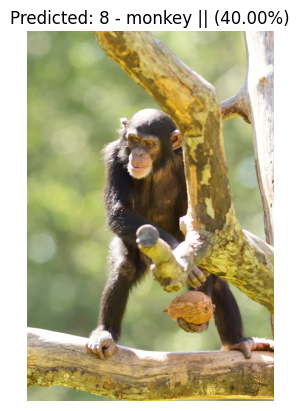

In [ ]:
img_path = "/content/drive/MyDrive/AWA2_dataset/Test classes/chimpanzee/chimpanzee_10001.jpg"
show_prediction(img_path)

In [ ]:
def evaluate_model(test_labels, pred_labels):
    '''
    This function is use to model evaluation.

    Input:
    test_labels : Actual test lebels.
    pred_labels : Predicted labels.

    Output: None

    '''
    # Accuracy
    acc = accuracy_score(test_labels, pred_labels)

    # Log loss
    loss = 1 - acc

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(test_labels, pred_labels)

    # Print results
    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:
def prediction_generator(image_paths, csv_file_path = "prediction_results.csv"):
    for img_path in image_paths:
        try:
            # act_class = img_path.split('/')[-2]
            act_class = os.path.basename(os.path.dirname(img_path))
            # Preprocess image
            img = image.load_img(img_path, target_size=(224, 224))
            img_array = image.img_to_array(img)
            img_array = preprocess_input(img_array)
            img_array = np.expand_dims(img_array, axis=0)

            # Extract features & predict
            features = feature_extractor.predict(img_array, verbose=0)
            probs = rf_model.predict_proba(features)[0]
            predicted_class = rf_model.classes_[np.argmax(probs)]
            class_name = idx_to_class[predicted_class]
            confidence = np.max(probs)

            # Write header once
            if not os.path.exists(csv_file_path):
                with open(csv_file_path, mode='w', newline='') as f:
                    writer = csv.writer(f)
                    writer.writerow(["Image Path", "Actual Class", "Predicted Class", "Class Name", "Probability"])

            # Log to CSV
            with open(csv_file_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([img_path, act_class, predicted_class, class_name, f"{confidence:.4f}"])

            # Yield the result
            yield {
                "img_path": img_path,
                "act_class": act_class,
                "predicted_class": predicted_class,
                "class_name": class_name,
                "confidence": confidence
            }

        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue



In [ ]:
import os

cwd = os.getcwd()
print("Current working directory:", cwd)

Current working directory: /content


In [ ]:
# Predict for all images in a folder
import glob

img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test" # '../Dataset/artefact2/test/*/*'
image_paths = glob.glob(img_dir)

unseen_csv_file_path = "prediction_results_generator_unseen.csv"

for result in prediction_generator(image_paths, csv_file_path=unseen_csv_file_path):
    # print(result)
    pass

df = pd.read_csv(unseen_csv_file_path)
df.head()

Error processing /content/drive/MyDrive/AWA2_dataset/Trial_test: [Errno 21] Is a directory: '/content/drive/MyDrive/AWA2_dataset/Trial_test'


FileNotFoundError: [Errno 2] No such file or directory: 'prediction_results_generator_unseen.csv'

In [ ]:
import os
import glob
import pandas as pd

img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test"
image_paths = glob.glob(os.path.join(img_dir, "**", "*.jpg"), recursive=True)

print(f"Found {len(image_paths)} images.")

unseen_csv_file_path = "prediction_results_generator_unseen.csv"

for result in prediction_generator(image_paths, csv_file_path=unseen_csv_file_path):
    pass

df = pd.read_csv(unseen_csv_file_path)
df.head()


Found 100 images.
Error processing /content/drive/MyDrive/AWA2_dataset/Trial_test/raccoon/raccoon_10005.jpg: np.int64(15)
Error processing /content/drive/MyDrive/AWA2_dataset/Trial_test/raccoon/raccoon_10008.jpg: np.int64(15)
Error processing /content/drive/MyDrive/AWA2_dataset/Trial_test/raccoon/raccoon_10004.jpg: np.int64(9)
Error processing /content/drive/MyDrive/AWA2_dataset/Trial_test/raccoon/raccoon_10007.jpg: np.int64(5)
Error processing /content/drive/MyDrive/AWA2_dataset/Trial_test/raccoon/raccoon_10002.jpg: np.int64(11)
Error processing /content/drive/MyDrive/AWA2_dataset/Trial_test/raccoon/raccoon_10003.jpg: np.int64(9)


KeyboardInterrupt: 

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test"  # '../Dataset/artefact2/test/*'
image_class = sorted([name for name in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, name))])

idx_to_unseen_class = {k: v for k, v in enumerate(image_class)}

words = list(idx_to_unseen_class.values()) # ['tiger', 'lion', 'cat', 'dog', 'truck']
embeddings = model.encode(words, convert_to_tensor=True)
similar_wds = []

for _, row in df.iterrows():
#     print(row[-2])
    # Find top n similar
    query = model.encode(row[-2], convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    # Show top-3 results
    top_results = torch.topk(cosine_scores[0], k=5)
    wds, cos_scores = [], []
    for idx in top_results.indices:
#         print(words[idx], float(cosine_scores[0][idx]))
        wds.append(words[idx])
        cos_scores.append(round(float(cosine_scores[0][idx])*100,2))
#     break
    similar_wds.append((wds, cos_scores))

df['similar_wds'] = similar_wds
df.head()

/tmp/ipython-input-1230187639.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  query = model.encode(row[-2], convert_to_tensor=True)


TypeError: 'float' object is not subscriptable

In [ ]:
df.to_csv('prediction_results_generator_unseen.csv', index=False)

In [ ]:
df = pd.read_csv('prediction_results_generator_unseen.csv')
zsl_classes, unseen_class = [], []

for _, row in df.iterrows():
    ActualClass = row[1]
    SimilarWords = eval(row[-1])[0]

    if ActualClass in SimilarWords:
        zsl_classes.append(words.index(ActualClass))
        unseen_class.append(words.index(ActualClass))
    else:
        zsl_classes.append(words.index(SimilarWords[0]))
        unseen_class.append(words.index(ActualClass))

df['ZSL Predicted Class'] = zsl_classes
df['ZSL Unseen Class'] = unseen_class
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'prediction_results_generator_unseen.csv'

Accuracy: 70.00 %
Log Loss: 30.00 %
Cohen's Kappa Score: 66.67 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       1.00      0.10      0.18        10
           2       1.00      0.40      0.57        10
           3       0.48      1.00      0.65        10
           4       0.83      1.00      0.91        10
           5       0.90      0.90      0.90        10
           6       0.89      0.80      0.84        10
           7       0.57      0.80      0.67        10
           8       0.53      1.00      0.69        10
           9       1.00      0.10      0.18        10

    accuracy                           0.70       100
   macro avg       0.82      0.70      0.65       100
weighted avg       0.82      0.70      0.65       100



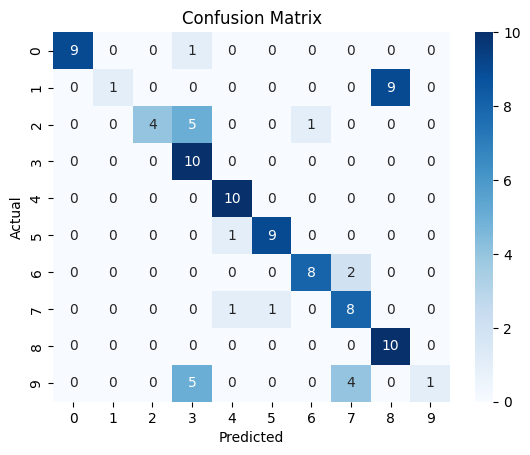

In [ ]:
test_labels, pred_labels = df['ZSL Unseen Class'], df['ZSL Predicted Class']
evaluate_model(test_labels, pred_labels)

# Need to check test classes of AWA2 dataset but as its very large need to do one one class and save csv , then end we will merge the csv#


In [ ]:
img_dir = "/content/drive/MyDrive/AWA2_dataset/Trial_test"

# list all class folders
class_folders = sorted([name for name in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, name))])
print(class_folders)


['chimpanzee', 'giant_panda', 'hippopotamus', 'humpback_whale', 'leopard', 'persian_cat', 'pig', 'raccoon', 'rat', 'seal']


In [ ]:
import os
import glob
import pandas as pd

img_dir = "/content/drive/MyDrive/AWA2_dataset/Test classes"
class_name = "seal"  # <-- choose your class folder here

class_dir = os.path.join(img_dir, class_name)

# get all images inside this class folder
image_paths = glob.glob(os.path.join(class_dir, "*.jpg"))

print(f"Found {len(image_paths)} images in class '{class_name}'.")

unseen_csv_file_path = f"prediction_results_{class_name}.csv"

for result in prediction_generator(image_paths, csv_file_path=unseen_csv_file_path):
    pass

df = pd.read_csv(unseen_csv_file_path)
df.head()


Found 988 images in class 'seal'.


,Image Path,Actual Class,Predicted Class,Class Name,Probability
0,/content/drive/MyDrive/AWA2_dataset/Test class...,seal,17,walrus,0.29
1,/content/drive/MyDrive/AWA2_dataset/Test class...,seal,0,bear,0.23
2,/content/drive/MyDrive/AWA2_dataset/Test class...,seal,17,walrus,0.38
3,/content/drive/MyDrive/AWA2_dataset/Test class...,seal,17,walrus,0.40
4,/content/drive/MyDrive/AWA2_dataset/Test class...,seal,9,mouse,0.21


In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

img_dir = "/content/drive/MyDrive/AWA2_dataset/Test classes"  # '../Dataset/artefact2/test/*'
image_class = sorted([name for name in os.listdir(img_dir) if os.path.isdir(os.path.join(img_dir, name))])

idx_to_unseen_class = {k: v for k, v in enumerate(image_class)}

words = list(idx_to_unseen_class.values()) # ['tiger', 'lion', 'cat', 'dog', 'truck']
embeddings = model.encode(words, convert_to_tensor=True)
similar_wds = []

for _, row in df.iterrows():
#     print(row[-2])
    # Find top n similar
    query = model.encode(row[-2], convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    # Show top-3 results
    top_results = torch.topk(cosine_scores[0], k=10)
    wds, cos_scores = [], []
    for idx in top_results.indices:
#         print(words[idx], float(cosine_scores[0][idx]))
        wds.append(words[idx])
        cos_scores.append(round(float(cosine_scores[0][idx])*100,2))
#     break
    similar_wds.append((wds, cos_scores))

df['similar_wds'] = similar_wds
df.head()

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipython-input-14-1404740999.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  query = model.encode(row[-2], convert_to_tensor=True)


,Image Path,Actual Class,Predicted Class,Class Name,Probability,similar_wds
0,/content/drive/MyDrive/AWA2_dataset/Test class...,seal,17,walrus,0.29,"([humpback_whale, leopard, persian_cat, raccoo..."
1,/content/drive/MyDrive/AWA2_dataset/Test class...,seal,0,bear,0.23,"([rat, pig, raccoon, leopard, humpback_whale, ..."
2,/content/drive/MyDrive/AWA2_dataset/Test class...,seal,17,walrus,0.38,"([humpback_whale, leopard, persian_cat, raccoo..."
3,/content/drive/MyDrive/AWA2_dataset/Test class...,seal,17,walrus,0.40,"([humpback_whale, leopard, persian_cat, raccoo..."
4,/content/drive/MyDrive/AWA2_dataset/Test class...,seal,9,mouse,0.21,"([rat, leopard, raccoon, hippopotamus, pig, ch..."


In [ ]:
df.to_csv(f"prediction_results_{class_name}.csv", index=False)

In [ ]:
import pandas as pd

# List of full paths to your 10 CSV files
csv_files = [
    "/content/prediction_results_chimpanzee.csv",
    "/content/prediction_results_giant_panda.csv",
    "/content/prediction_results_hippopotamus.csv",
    "/content/prediction_results_humpback_whale.csv",
    "/content/prediction_results_leopard.csv",
    "/content/prediction_results_persian_cat.csv",
    "/content/prediction_results_pig.csv",
    "/content/prediction_results_raccoon.csv",
    "/content/prediction_results_rat.csv",
    "/content/prediction_results_seal.csv"
]

# Read and combine them
dfs = [pd.read_csv(file) for file in csv_files]

# Combine row-wise
combined_df = pd.concat(dfs, ignore_index=True)

# Save the combined CSV
combined_df.to_csv("Complete_AWA2_unseen.csv", index=False)

print("All files combined successfully!")


All files combined successfully!


In [ ]:
df = pd.read_csv('Complete_AWA2_unseen.csv')
zsl_classes, unseen_class = [], []

for _, row in df.iterrows():
    ActualClass = row[1]
    SimilarWords = eval(row[-1])[0]

    if ActualClass in SimilarWords:
        zsl_classes.append(words.index(ActualClass))
        unseen_class.append(words.index(ActualClass))
    else:
        zsl_classes.append(words.index(SimilarWords[0]))
        unseen_class.append(words.index(ActualClass))

df['ZSL Predicted Class'] = zsl_classes
df['ZSL Unseen Class'] = unseen_class
df.head()

/tmp/ipython-input-18-229600960.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ActualClass = row[1]
/tmp/ipython-input-18-229600960.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  SimilarWords = eval(row[-1])[0]


,Image Path,Actual Class,Predicted Class,Class Name,Probability,similar_wds,ZSL Predicted Class,ZSL Unseen Class
0,/content/drive/MyDrive/AWA2_dataset/Trial_test...,chimpanzee,17,walrus,0.18,"(['humpback_whale', 'leopard', 'persian_cat', ...",3,0
1,/content/drive/MyDrive/AWA2_dataset/Trial_test...,chimpanzee,8,monkey,0.30,"(['chimpanzee', 'rat', 'leopard', 'raccoon', '...",0,0
2,/content/drive/MyDrive/AWA2_dataset/Trial_test...,chimpanzee,8,monkey,0.33,"(['chimpanzee', 'rat', 'leopard', 'raccoon', '...",0,0
3,/content/drive/MyDrive/AWA2_dataset/Trial_test...,chimpanzee,8,monkey,0.31,"(['chimpanzee', 'rat', 'leopard', 'raccoon', '...",0,0
4,/content/drive/MyDrive/AWA2_dataset/Trial_test...,chimpanzee,8,monkey,0.42,"(['chimpanzee', 'rat', 'leopard', 'raccoon', '...",0,0


Accuracy: 84.49 %
Log Loss: 15.51 %
Cohen's Kappa Score: 82.67 %

classification_report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       738
           1       1.00      1.00      1.00       874
           2       1.00      0.40      0.57       684
           3       0.62      1.00      0.77       709
           4       0.80      1.00      0.89       720
           5       0.92      0.75      0.83       747
           6       0.92      0.59      0.72       713
           7       0.66      0.72      0.69       512
           8       0.69      1.00      0.82       310
           9       1.00      1.00      1.00       988

    accuracy                           0.84      6995
   macro avg       0.85      0.84      0.82      6995
weighted avg       0.88      0.84      0.84      6995



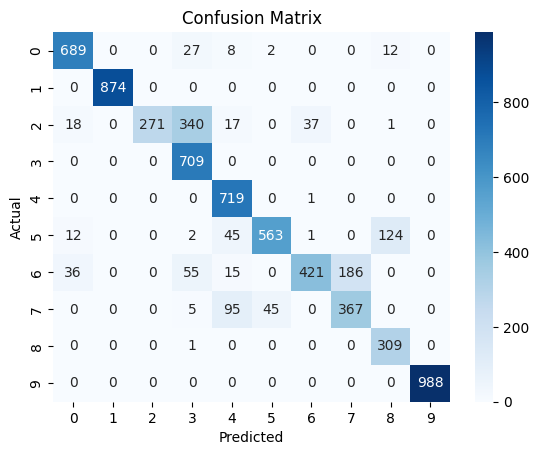

In [ ]:
test_labels, pred_labels = df['ZSL Unseen Class'], df['ZSL Predicted Class']
evaluate_model(test_labels, pred_labels)

| Class No | Class Name      | Support (actual samples) |
| -------- | --------------- | ------------------------ |
| 0        | chimpanzee      | 738                      |
| 1        | giant\_panda    | 874                      |
| 2        | hippopotamus    | 684                      |
| 3        | humpback\_whale | 709                      |
| 4        | leopard         | 720                      |
| 5        | persian\_cat    | 747                      |
| 6        | pig             | 713                      |
| 7        | raccoon         | 512                      |
| 8        | rat             | 310                      |
| 9        | seal            | 988                      |
